In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from ISLP import load_data

Auto = load_data("Auto")
Auto.shape

(392, 8)

In [3]:
Auto.columns

Index(['mpg', 'cylinders', 'displacement', 'horsepower', 'weight',
       'acceleration', 'year', 'origin'],
      dtype='object')

In [4]:
# Median calculation
median_mpg = Auto['mpg'].median()

print("Median MPG:", median_mpg)

Median MPG: 22.75


In [5]:
# Creating MPG01 and assign values based on median value
Auto['mpg01'] = (Auto['mpg'] > median_mpg).astype(int)


In [11]:
Auto[['mpg', 'mpg01']].tail(10)

,mpg,mpg01
name,,
chrysler lebaron medallion,26.0,1
ford granada l,22.0,0
toyota celica gt,32.0,1
dodge charger 2.2,36.0,1
chevrolet camaro,27.0,1
ford mustang gl,27.0,1
vw pickup,44.0,1
dodge rampage,32.0,1
ford ranger,28.0,1


In [10]:
## obeservation in each mpg01
Auto['mpg01'].value_counts()

mpg01
0    196
1    196
Name: count, dtype: int64

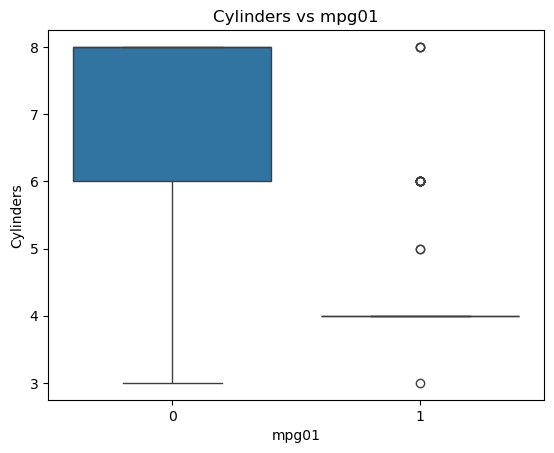

In [12]:
## B graphs
sns.boxplot(x='mpg01', y='cylinders', data=Auto)

plt.xlabel('mpg01')
plt.ylabel('Cylinders')
plt.title('Cylinders vs mpg01')
plt.show()

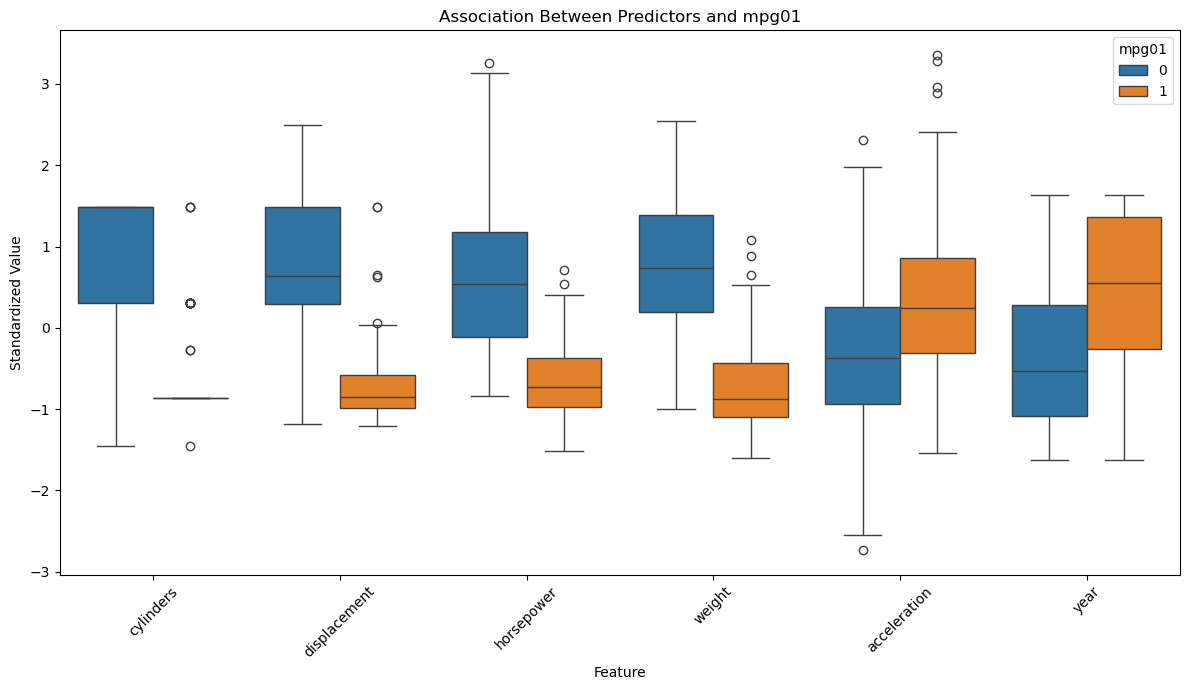

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

features = ['cylinders', 'displacement', 'horsepower',
            'weight', 'acceleration', 'year']

# Create a copy for visualization
plot_data = Auto[features + ['mpg01']].copy()

# Standardize the predictor variables
for column in features:
    plot_data[column] = (
        plot_data[column] - plot_data[column].mean()
    ) / plot_data[column].std()

# Convert to long format
plot_data = plot_data.melt(
    id_vars='mpg01',
    var_name='Feature',
    value_name='Standardized Value'
)

# Plot
plt.figure(figsize=(12, 7))

sns.boxplot(
    data=plot_data,
    x='Feature',
    y='Standardized Value',
    hue='mpg01'
)

plt.xlabel('Feature')
plt.ylabel('Standardized Value')
plt.title('Association Between Predictors and mpg01')
plt.xticks(rotation=45)
plt.legend(title='mpg01')

plt.tight_layout()
plt.show()

The graphs show that the models are able to clearly separate the two classes, with most observations correctly classified. For example, in the logistic regression graph, most points are positioned on the correct side of the decision boundary, indicating a strong classification performance. Similarly, in the Naive Bayes graph, the majority of observations are also correctly grouped according to their class, although a few points overlap or are misclassified. Overall, the graphs suggest that both models perform well, with only a small number of observations falling on the wrong side of the decision boundary.

In [14]:
## Spliting data into Testing and trainng data
from sklearn.model_selection import train_test_split

X = Auto[['cylinders', 'displacement', 'horsepower', 'weight', 'year']]
y = Auto['mpg01']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.5,
    random_state=1,
    stratify=y
)

print("Training set:", X_train.shape)
print("Test set:", X_test.shape)

Training set: (196, 5)
Test set: (196, 5)


In [15]:
## LDA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import accuracy_score

lda = LinearDiscriminantAnalysis()

lda.fit(X_train, y_train)

y_pred_lda = lda.predict(X_test)

lda_accuracy = accuracy_score(y_test, y_pred_lda)
lda_error = 1 - lda_accuracy

print("LDA Accuracy:", lda_accuracy)
print("LDA Test Error:", lda_error)

LDA Accuracy: 0.9030612244897959
LDA Test Error: 0.09693877551020413


In [16]:
## Confusion matrix
from sklearn.metrics import confusion_matrix

print(confusion_matrix(y_test, y_pred_lda))

[[84 14]
 [ 5 93]]


In [17]:
## QDA
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis

qda = QuadraticDiscriminantAnalysis()

qda.fit(X_train, y_train)

y_pred_qda = qda.predict(X_test)

qda_accuracy = accuracy_score(y_test, y_pred_qda)
qda_error = 1 - qda_accuracy

print("QDA Accuracy:", qda_accuracy)
print("QDA Test Error:", qda_error)

QDA Accuracy: 0.8826530612244898
QDA Test Error: 0.11734693877551017


In [18]:
## QDA Confusion Matrix
print(confusion_matrix(y_test, y_pred_qda))

[[86 12]
 [11 87]]


In [19]:
## Logistic Regression
from sklearn.linear_model import LogisticRegression

logistic = LogisticRegression(max_iter=10000)

logistic.fit(X_train, y_train)

y_pred_logistic = logistic.predict(X_test)

logistic_accuracy = accuracy_score(y_test, y_pred_logistic)
logistic_error = 1 - logistic_accuracy

print("Logistic Regression Accuracy:", logistic_accuracy)
print("Logistic Regression Test Error:", logistic_error)

Logistic Regression Accuracy: 0.8979591836734694
Logistic Regression Test Error: 0.10204081632653061


In [20]:
print(confusion_matrix(y_test, y_pred_logistic))

[[85 13]
 [ 7 91]]


In [21]:
## Naive Bayes
from sklearn.naive_bayes import GaussianNB

model = GaussianNB()

model.fit(X_train, y_train)

y_pred_nb = model.predict(X_test)

nb_accuracy = accuracy_score(y_test, y_pred_nb)
nb_error = 1 - nb_accuracy

print("Naive Bayes Accuracy:", nb_accuracy)
print("Naive Bayes Test Error:", nb_error)

Naive Bayes Accuracy: 0.8877551020408163
Naive Bayes Test Error: 0.11224489795918369


In [22]:
print(confusion_matrix(y_test, y_pred_nb))

[[84 14]
 [ 8 90]]


In [23]:
## KNN
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [24]:
k_values = [1, 3, 5, 7, 9, 11, 15, 20, 25]

knn_errors = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)

    y_pred_knn = knn.predict(X_test_scaled)

    error = 1 - accuracy_score(y_test, y_pred_knn)
    knn_errors.append(error)

    print(f"K = {k}, Test Error = {error:.4f}")

K = 1, Test Error = 0.0765
K = 3, Test Error = 0.0816
K = 5, Test Error = 0.0918
K = 7, Test Error = 0.1020
K = 9, Test Error = 0.1122
K = 11, Test Error = 0.1122
K = 15, Test Error = 0.1122
K = 20, Test Error = 0.1122
K = 25, Test Error = 0.1020


In [25]:
best_k = k_values[knn_errors.index(min(knn_errors))]

print("Best K:", best_k)
print("Lowest Test Error:", min(knn_errors))

Best K: 1
Lowest Test Error: 0.07653061224489799


In [26]:
results = pd.DataFrame({
    'Model': [
        'LDA',
        'QDA',
        'Logistic Regression',
        'Naive Bayes'
    ],
    'Test Error': [
        lda_error,
        qda_error,
        logistic_error,
        nb_error
    ]
})

print(results)

                 Model  Test Error
0                  LDA    0.096939
1                  QDA    0.117347
2  Logistic Regression    0.102041
3          Naive Bayes    0.112245


In [27]:
knn_results = pd.DataFrame({
    'K': k_values,
    'Test Error': knn_errors
})

print(knn_results)

    K  Test Error
0   1    0.076531
1   3    0.081633
2   5    0.091837
3   7    0.102041
4   9    0.112245
5  11    0.112245
6  15    0.112245
7  20    0.112245
8  25    0.102041


Overall, LDA performed the best, with the lowest test error of 9.69%, followed by Logistic Regression (10.20%), Naive Bayes (11.22%), and QDA (11.73%). Therefore, among these four models, LDA provides the best predictive performance on the test data.